# Exploratory Data Analysis

This notebook explores the Walmart sales forecasting dataset.


In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect("../db/sales.db")

df = pd.read_sql(
    "SELECT * FROM train_dataset",
    conn,
)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Store_Type,Store_Size
0,1,1,2010-02-05,24924.50,0,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,1,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,0,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,0,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,0,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [3]:
df.shape

(421570, 16)

## Dataset Overview

The training dataset contains historical sales records enriched with
store metadata and economic indicators.

The target variable is `Weekly_Sales`.

In [4]:
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  int64  
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Store_Type    421570 non-null  str    
 15  Store_Size    421570 non-null  int64  
dtypes: float64(10), int64(4), str(2)
memory usage: 51.5 MB


,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Store_Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,0.070358,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,0.255750,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,0.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,0.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,0.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,0.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,1.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


## Missing Values


In [5]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
)

missing

MarkDown2       310322
MarkDown4       286603
MarkDown3       284479
MarkDown1       270889
MarkDown5       270138
Store                0
Date                 0
Dept                 0
Fuel_Price           0
Temperature          0
IsHoliday            0
Weekly_Sales         0
CPI                  0
Unemployment         0
Store_Type           0
Store_Size           0
dtype: int64

### Findings

Markdown variables contain a significant amount of missing values.

This behaviour is expected because promotional campaigns are not active
for every store and date.

Potential strategies:

- Fill missing values with zero
- Create promotion indicator flags

## Target Variable Analysis

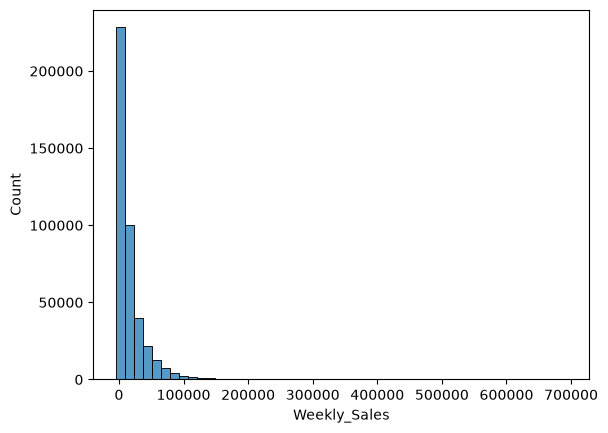

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df["Weekly_Sales"],
    bins=50,
)

plt.show()

In [7]:
# Show the 5 absolute maximum values
print(df["Weekly_Sales"].nlargest(5))

95373     693099.36
338013    649770.18
95425     630999.19
337961    627962.93
135665    474330.10
Name: Weekly_Sales, dtype: float64


The data is heavily right-skewed (positively skewed). The majority of weekly sales values are concentrated near zero to lower ranges (roughly under $50,000), with a massive count exceeding 200,000 instances in the lowest bin.
There is a long tail extending up to nearly $700,000. These high values represent extreme outliers or exceptional high-volume sales weeks/stores.

## Time Series Analysis

<Axes: xlabel='Date'>

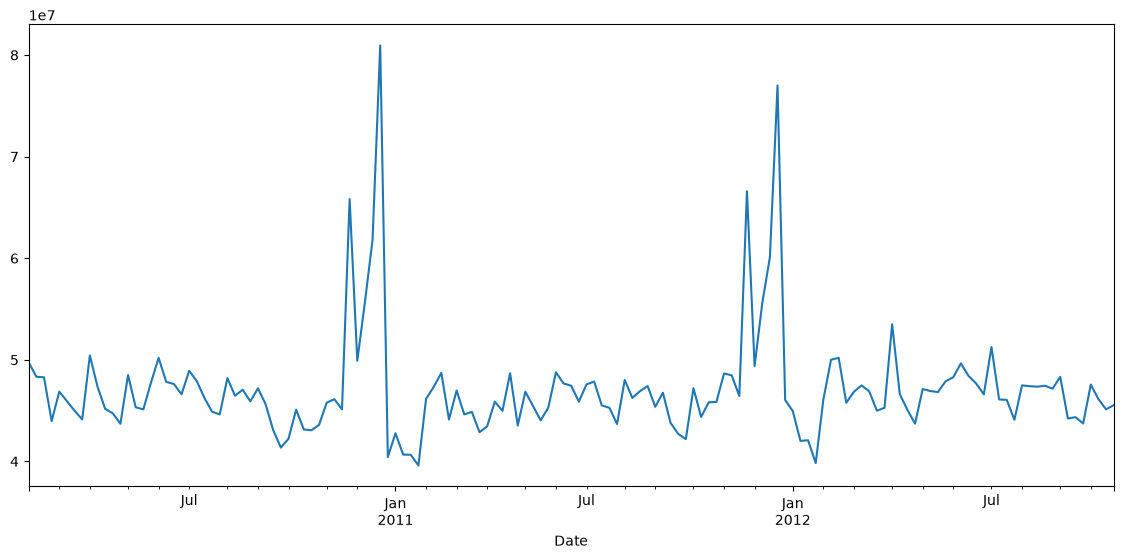

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

sales_over_time = (
    df.groupby("Date")["Weekly_Sales"]
    .sum()
)

sales_over_time.plot(
    figsize=(14, 6)
)

### Findings

The series shows clear seasonality patterns.

Sales spikes are visible during holiday periods, suggesting the
importance of time-based features.

## Holiday Impact

In [9]:
df.groupby(
    "IsHoliday"
)["Weekly_Sales"].mean()

IsHoliday
0    15901.445069
1    17035.823187
Name: Weekly_Sales, dtype: float64

<Axes: xlabel='IsHoliday', ylabel='Weekly_Sales'>

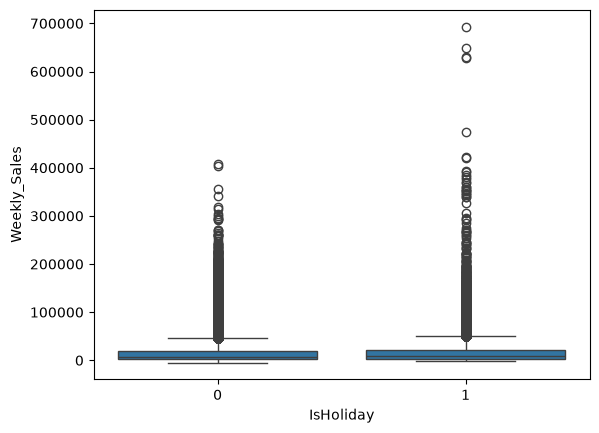

In [10]:
sns.boxplot(
    data=df,
    x="IsHoliday",
    y="Weekly_Sales",
)

### Findings

Holiday weeks exhibit higher sales variability. The holiday indicator should be retained as a predictive feature.

## Store Analysis

In [11]:
store_sales = (
    df.groupby("Store")["Weekly_Sales"]
    .mean()
)

store_sales.sort_values(
    ascending=False
).head(10)

Store
20    29508.301592
4     29161.210415
14    28784.851727
13    27355.136891
2     26898.070031
10    26332.303819
27    24826.984536
6     21913.243624
1     21710.543621
39    21000.763562
Name: Weekly_Sales, dtype: float64

Store 20 leads the fleet with the highest average weekly sales

<Axes: xlabel='Store_Type', ylabel='Weekly_Sales'>

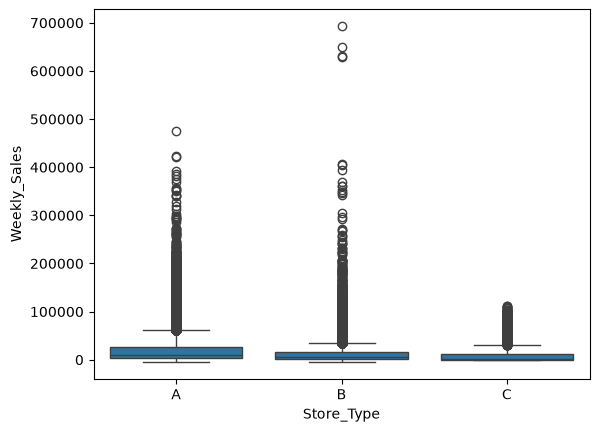

In [12]:
sns.boxplot(
    data=df,
    x="Store_Type",
    y="Weekly_Sales",
)

### Findings

Store categories show different sales behaviours. Store metadata is expected to improve forecasting performance.

## Economic Variables

<Axes: >

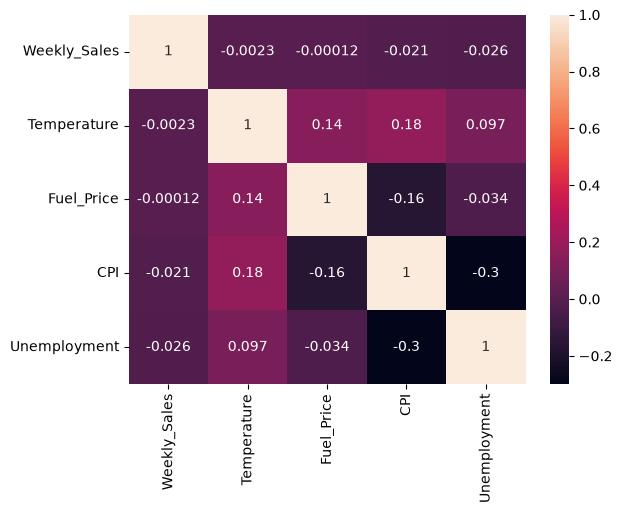

In [13]:
numeric_cols = [
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
)


### Findings

Economic indicators display weak to none correlations with sales. Further modelling is required to assess their predictive contribution.


## MarkDown Analysis

In [14]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
]

df[markdown_cols].describe()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
count,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000
mean,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079
std,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455
min,0.270000,-265.760000,-29.100000,0.220000,135.160000
25%,2240.270000,41.600000,5.080000,504.220000,1878.440000
50%,5347.450000,192.000000,24.600000,1481.310000,3359.450000
75%,9210.900000,1926.940000,103.990000,3595.040000,5563.800000
max,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000


In [15]:
(
    df[markdown_cols]
    .isna()
    .mean()
    * 100
)

MarkDown1    64.257181
MarkDown2    73.611025
MarkDown3    67.480845
MarkDown4    67.984676
MarkDown5    64.079038
dtype: float64

### Findings

Markdown variables contain extensive missing data. Rather than dropping them, missing values will likely be interpreted as
absence of promotional activity.

# EDA Conclusions

Key findings:

1. Holiday periods affect sales volume.

2. Weekly sales exhibit strong seasonality.

3. Store characteristics contribute to sales differences.

4. Economic indicators may provide additional context.

5. Promotional markdown variables contain many missing values.